This is the initial simulation, \vers{I} is assumed to be in the x-y plane for dim=2 and x-z for dim=3.
In this plane [0,-1,0] is the psi=0 direction.

In [49]:
import numpy as np
from matplotlib import pyplot as plt

# import numba as nb

In [50]:
# System parameters

dim = 2

D_n = 0.1 #0.5
D_r = 0.
V0 = 1.
r_0 = 10.

epsilon = 10**(-3)

vec_I = np.zeros(dim)
vec_I[-1] = -1

In [51]:
# Domain parameters

L = 5
domain_dims = L*np.ones(dim)

In [52]:
# Simulation parameters

N_samples = 100 #10**3
nt = 200 #800    # number of times steps

dt = 5*10**-2
if not dt < 0.01 / D_n:
    raise Exception("too large time step")

In [53]:
# Gaussian beam parameters

r_c = 0.5
sigma_beam = 0.5

In [54]:
# Initial condidtions for r, n 

r0 = domain_dims[:,None]/2*np.ones((dim, N_samples)) # r0 = np.zeros((dim, N_samples))

n0 = np.zeros((dim,N_samples))
n0[0,:] = 1 # n0[-1,:] = 1


r = r0 # initial position
n = n0 # initial orientation

In [55]:
# Tensor for saving positions

r_history = np.zeros((nt+1, dim, N_samples))
r_history[0,:,:] = r0

In [56]:
def enforce_PBC(r, pbc_dim, domain_dims): # r.shape = (dim, N_samples)
    r[pbc_dim,:] = np.mod(r[pbc_dim,:],domain_dims[pbc_dim])

def enforce_bounceback(r, bb_dim, domain_dims): # r.shape = (dim, N_samples)
    x_bb = r[bb_dim,:]
    Lx = domain_dims[bb_dim]
    x_bb = np.mod(x_bb, 2*Lx)
    x_bb = Lx - np.abs(x_bb - Lx)
    r[bb_dim,:] = x_bb


def I(r):   # (dim, sample)
    return np.exp(-(r[0,:]-r_c)**2/(2*sigma_beam**2)) # Gaussian spread in x for 2d, 3d

def f(x):
    return 0.3*np.sin(x)  # f2-f1 #TODO implement better approximation or original functions

def Omega(I,psi):  # we later take x = I(r)*sin(psi)
    x=I*np.sin(psi)
    return f(x)


zeta_n = np.random.normal(loc=0,scale=1,size = (nt, dim, N_samples))
zeta_r = np.random.normal(loc=0,scale=1,size = (nt, dim, N_samples))

dn_rand = np.sqrt(2*D_n*dt)*zeta_n
dr_rand = np.sqrt(2*D_r*dt)*zeta_r

In [57]:
# Time evolution

for it in range(nt):
    dot_prod = np.sum(-vec_I[:, None] * n, axis=0) # (N_samples,)
    psi = np.arccos(dot_prod) # (N_samples,), I(r) has shape (N_samples,) too
    dn_rot = dt*Omega(I(r), psi)*(-dot_prod*n -vec_I[:,None]) 

    dn = dn_rand[it,:,:] # noise term
    dn -= n*np.sum(n*dn, axis=0) # project onto tangent space


    n += dn + dn_rot
    n /= np.linalg.norm(n, axis=0)
    
    r = n*V0*dt + r + dr_rand[it,:]

    enforce_PBC(r, pbc_dim=0, domain_dims=domain_dims)
    enforce_bounceback(r, bb_dim=1, domain_dims=domain_dims)
    r_history[it+1,:,:] = r

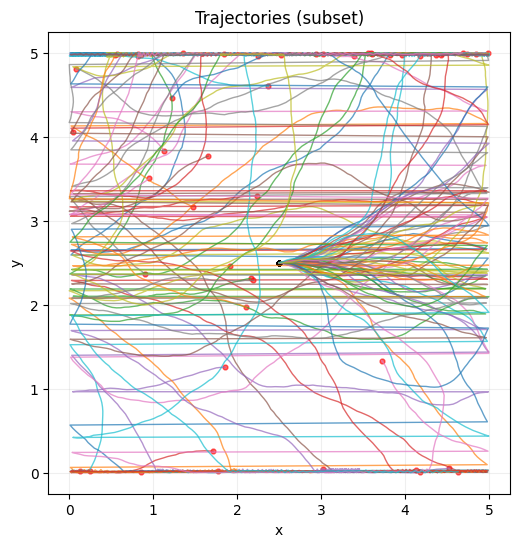

In [58]:
# Visualize trajectories in r_history
# r_history shape: (nt+1, dim, N_samples)

n_show = min(50, N_samples)           # number of trajectories to plot
idx = np.linspace(0, N_samples - 1, n_show, dtype=int)

t = np.arange(r_history.shape[0])

if dim == 2:
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in idx:
        ax.plot(r_history[:, 0, i], r_history[:, 1, i], lw=1, alpha=0.7)
        ax.scatter(r_history[0, 0, i], r_history[0, 1, i], s=10, c="k", alpha=0.6)
        ax.scatter(r_history[-1, 0, i], r_history[-1, 1, i], s=12, c="r", alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Trajectories (subset)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)
    plt.show()

elif dim == 3:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    for i in idx:
        ax.plot(r_history[:, 0, i], r_history[:, 1, i], r_history[:, 2, i], lw=1, alpha=0.7)
        ax.scatter(r_history[0, 0, i], r_history[0, 1, i], r_history[0, 2, i], s=10, c="k", alpha=0.6)
        ax.scatter(r_history[-1, 0, i], r_history[-1, 1, i], r_history[-1, 2, i], s=12, c="r", alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Trajectories (subset)")
    plt.show()

In [59]:
# for checking how asymmetric abp distribution is around zero

y_final = r_history[-1,0,:]
if_positive = y_final>0
if_negative = y_final<0
n_positive = np.sum(if_positive)
n_negative = np.sum(if_negative)
print(n_negative, n_positive)

0 100
